In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, math, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer, AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments, Trainer,
    TrainerCallback, EarlyStoppingCallback,
    set_seed,
)
from datasets import Dataset

warnings.filterwarnings('ignore')
set_seed(42)
print('✅ Imports OK')

✅ Imports OK


In [3]:
BASE_ROOT = Path('/content/drive/MyDrive/Rajdeep_Document')

PATHS = dict(
    task_csv     = BASE_ROOT / 'data'    / 'climate_train.csv',

    # ── TAPT starts from BASE MiniLM, not DAPT ────────────────────
    base_model   = 'microsoft/MiniLM-L12-H384-uncased',

    model_dir    = BASE_ROOT / 'models'  / 'final' / 'tapt_minilm_climate',
    lr_sweep_dir = BASE_ROOT / 'models'  / 'tapt_lr_sweep',
    log_dir      = BASE_ROOT / 'logs'    / 'tapt',
    log_csv      = BASE_ROOT / 'logs'    / 'tapt' / 'tapt_training_logs.csv',
    results_dir  = BASE_ROOT / 'results' / 'tapt',
    eval_json    = BASE_ROOT / 'results' / 'tapt' / 'tapt_evaluation_results.json',
    report_txt   = BASE_ROOT / 'results' / 'tapt' / 'tapt_comparison_report.txt',
    plots_dir    = BASE_ROOT / 'plots'   / 'tapt',
)

for p in [PATHS['model_dir'], PATHS['lr_sweep_dir'], PATHS['log_dir'],
          PATHS['results_dir'], PATHS['plots_dir']]:
    Path(p).mkdir(parents=True, exist_ok=True)

PATHS = {k: str(v) for k, v in PATHS.items()}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

🖥️  Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


In [5]:
# ── LR sweep: same range as DAPT since we start from base MiniLM ──
TAPT_LR_SWEEP = [1e-5, 3e-5, 5e-5]

CFG = dict(
    # TAPT starts from base MiniLM directly

    text_column      = 'text_clean',
    seq_len          = 128,
    mlm_probability  = 0.15,
    tapt_epochs      = 50,
    sweep_epochs     = 10,
    sweep_batch      = 16,
    full_batch       = 16,
    warmup_ratio     = 0.06,
    weight_decay     = 0.01,
    val_split        = 0.10,
    early_stop_patience = 5,
    seed             = 42,
    **PATHS,
)

print('TAPT Config ready.')
print(f'   Starting model   : {CFG["base_model"]}  (base MiniLM, no DAPT)')
print(f'   LR sweep values  : {TAPT_LR_SWEEP}')
print(f'   Sweep epochs     : {CFG["sweep_epochs"]}')
print(f'   Full TAPT epochs : {CFG["tapt_epochs"]}')
print(f'   Seq length       : {CFG["seq_len"]} tokens')
print(f'   Dynamic masking  : ON (mask_prob={CFG["mlm_probability"]})')
print(f'   Early stopping   : patience={CFG["early_stop_patience"]}')

TAPT Config ready.
   Starting model   : microsoft/MiniLM-L12-H384-uncased  (base MiniLM, no DAPT)
   LR sweep values  : [1e-05, 3e-05, 5e-05]
   Sweep epochs     : 10
   Full TAPT epochs : 50
   Seq length       : 128 tokens
   Dynamic masking  : ON (mask_prob=0.15)
   Early stopping   : patience=5


In [ ]:
# ── TAPT corpus = labeled task training set used WITHOUT its labels ─────────

df = pd.read_csv(PATHS['task_csv'])
print(f'Task corpus shape   : {df.shape}')
print(f'Columns available   : {list(df.columns)}')
print(f'Nulls in text_clean : {df["text_clean"].isnull().sum()}')

# Keep only the text column; everything else is irrelevant for MLM
df = df[['text_clean']].dropna()
df['text_clean'] = df['text_clean'].astype(str).str.strip()
df = df[df['text_clean'].str.len() > 20].reset_index(drop=True)

# Word count summary
df['_wc'] = df['text_clean'].str.split().str.len()
print(f'\nTask corpus rows     : {len(df):,}')
print(f'Total words          : {df["_wc"].sum():,}')
print(f'Avg words / sample   : {df["_wc"].mean():.1f}')
print(f'Max words / sample   : {df["_wc"].max()}')
df.drop(columns=['_wc'], inplace=True)

print('\n⚠️  Note: This is the TAPT corpus — same text the model will')
print('    be fine-tuned on downstream. Tight distribution alignment')
print('    is the point; small size is expected and intentional.')

Task corpus shape   : (15611, 6)
Columns available   : ['text_clean', 'source_file', 'folder', 'lang', 'word_count', 'climate_score']
Nulls in text_clean : 0

Task corpus rows     : 15,598
Total words          : 591,577
Avg words / sample   : 37.9
Max words / sample   : 512

⚠️  Note: This is the TAPT corpus — same text the model will
    be fine-tuned on downstream. Tight distribution alignment
    is the point; small size is expected and intentional.


In [7]:
# ── Load tokenizer from base MiniLM ──────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(CFG['base_model'])

TEXT_COL = CFG['text_column']

def tokenize_fn(examples):
    return tokenizer(
        examples[TEXT_COL],
        truncation=True,
        max_length=CFG['seq_len'],
        padding=False,
        return_special_tokens_mask=True,
    )

hf_ds     = Dataset.from_pandas(df)
tokenized = hf_ds.map(tokenize_fn, batched=True,
                       remove_columns=[TEXT_COL], desc='Tokenising')
split     = tokenized.train_test_split(test_size=CFG['val_split'],
                                       seed=CFG['seed'])
train_ds  = split['train']
eval_ds   = split['test']

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=CFG['mlm_probability'],
)

print(f'Tokenisation complete')
print(f'   Train samples  : {len(train_ds):,}')
print(f'   Eval  samples  : {len(eval_ds):,}')
print(f'   Dynamic masking: ON')

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenising:   0%|          | 0/15598 [00:00<?, ? examples/s]

Tokenisation complete
   Train samples  : 14,038
   Eval  samples  : 1,560
   Dynamic masking: ON


In [9]:
def compute_perplexity(model, eval_dataset, data_collator, batch_size, desc=None):
    model.eval()
    losses = []
    eval_dataloader = DataLoader(
        eval_dataset,
        batch_size=batch_size,
        collate_fn=data_collator,
        num_workers=2,
    )

    for batch in tqdm(eval_dataloader, desc=desc):
        with torch.no_grad():
            # Move batch to device
            batch = {k: v.to(model.device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            losses.append(loss.item())

    avg_loss = torch.mean(torch.tensor(losses))
    perplexity = torch.exp(avg_loss)
    return {'loss': avg_loss.item(), 'perplexity': perplexity.item()}

# ── Baseline = base MiniLM on task corpus BEFORE any TAPT ────────
print('Computing BASE MiniLM perplexity on task corpus (TAPT baseline)...')
base_model_eval = AutoModelForMaskedLM.from_pretrained(
    CFG['base_model']
).to(DEVICE)
base_model_eval.eval()

BASE_METRICS = compute_perplexity(
    base_model_eval, eval_ds, collator, batch_size=64, desc='Base Baseline'
)
print(f'\n   Base MiniLM — Loss      : {BASE_METRICS["loss"]}')
print(f'   Base MiniLM — Perplexity: {BASE_METRICS["perplexity"]}')
print(f'\n   (TAPT should reduce this on the climate task corpus.)')

del base_model_eval
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print('🧹 Base model freed.')

Computing BASE MiniLM perplexity on task corpus (TAPT baseline)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertForMaskedLM LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
pooler.dense.bias                          | UNEXPECTED | 
pooler.dense.weight                        | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.decoder.bias               | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.bias                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if

Base Baseline:   0%|          | 0/25 [00:00<?, ?it/s]


   Base MiniLM — Loss      : 11.248913764953613
   Base MiniLM — Perplexity: 76796.453125

   (TAPT should reduce this on the climate task corpus.)
🧹 Base model freed.


In [10]:
class DetailedLoggerCallback(TrainerCallback):
    def __init__(self):
        self.records      = []
        self._step_losses = []
        self._epoch_start = None

    def on_epoch_begin(self, args, state, control, **kwargs):
        self._epoch_start = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self._step_losses.append(logs['loss'])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        eval_loss  = metrics.get('eval_loss', float('nan'))
        ppl        = math.exp(eval_loss) if not math.isnan(eval_loss) else float('nan')
        train_loss = (sum(self._step_losses) / len(self._step_losses)
                      if self._step_losses else float('nan'))
        lr         = (state.log_history[-1].get('learning_rate', float('nan'))
                      if state.log_history else float('nan'))
        rec = dict(
            epoch         = int(round(state.epoch)),
            train_loss    = round(train_loss, 6),
            eval_loss     = round(eval_loss,  6),
            perplexity    = round(ppl,        4),
            learning_rate = lr,
            epoch_time_s  = round(time.time() - self._epoch_start, 2)
                            if self._epoch_start else None,
        )
        self.records.append(rec)
        self._step_losses = []
        print(f"  Ep {rec['epoch']:>3} | "
              f"Train {rec['train_loss']:.4f} | "
              f"Eval {rec['eval_loss']:.4f} | "
              f"PPL {rec['perplexity']:.3f} | "
              f"LR {rec['learning_rate']:.2e}")

print('✅ Callback ready.')

✅ Callback ready.


In [12]:
SWEEP_RESULTS = {}
BEST_LR       = None
BEST_LR_PPL   = float('inf')

print(f'LR Sweep: {len(TAPT_LR_SWEEP)} values × {CFG["sweep_epochs"]} epochs\n')

for lr in TAPT_LR_SWEEP:
    lr_key = f'lr={lr:.0e}'
    print(f'\n{"="*55}')
    print(f'  LR Sweep — {lr_key}')
    print(f'{"="*55}')

    # Always start from base MiniLM
    model  = AutoModelForMaskedLM.from_pretrained(CFG['base_model'])
    logger = DetailedLoggerCallback()

    steps_per_epoch = math.ceil(len(train_ds) / CFG['sweep_batch'])
    total_steps     = steps_per_epoch * CFG['sweep_epochs']
    warmup_steps    = max(1, int(total_steps * CFG['warmup_ratio']))
    sweep_out_dir   = f"{PATHS['lr_sweep_dir']}/{lr_key}"

    args = TrainingArguments(
        output_dir                  = sweep_out_dir,
        num_train_epochs            = CFG['sweep_epochs'],
        per_device_train_batch_size = CFG['sweep_batch'],
        per_device_eval_batch_size  = 64,
        learning_rate               = lr,
        weight_decay                = CFG['weight_decay'],
        warmup_steps                = warmup_steps,
        lr_scheduler_type           = 'cosine',
        fp16                        = False,
        eval_strategy               = 'epoch',
        save_strategy               = 'no',
        logging_steps               = max(5, steps_per_epoch // 4),
        report_to                   = 'none',
        seed                        = CFG['seed'],
        dataloader_num_workers      = 2,
        push_to_hub                 = False,
    )

    trainer = Trainer(
        model         = model,
        args          = args,
        train_dataset = train_ds,
        eval_dataset  = eval_ds,
        data_collator = collator,
        callbacks     = [logger],
    )

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    log_df    = pd.DataFrame(logger.records)
    final_ppl = log_df['perplexity'].iloc[-1]
    best_ppl  = log_df['perplexity'].min()

    SWEEP_RESULTS[lr_key] = {
        'lr'              : lr,
        'log_df'          : log_df,
        'final_perplexity': final_ppl,
        'best_perplexity' : best_ppl,
        'time_min'        : round(elapsed / 60, 2),
    }

    if final_ppl < BEST_LR_PPL:
        BEST_LR_PPL = final_ppl
        BEST_LR     = lr
        print(f'  New best LR: {lr:.0e}  PPL={final_ppl:.4f}')

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    print(f'  Done {elapsed/60:.1f} min | Final PPL={final_ppl:.4f}')

print(f'\n{"="*55}')
print(f'  LR Sweep Complete | Best LR={BEST_LR:.0e} | Best PPL={BEST_LR_PPL:.4f}')
print(f'{"="*55}')

LR Sweep: 3 values × 10 epochs


  LR Sweep — lr=1e-05


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertForMaskedLM LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
pooler.dense.bias                          | UNEXPECTED | 
pooler.dense.weight                        | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.decoder.bias               | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.bias                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if

Epoch,Training Loss,Validation Loss
1,5.806245,5.500965
2,5.046999,4.901017
3,4.774948,4.665048
4,4.584868,4.498996
5,4.521628,4.335962
6,4.398944,4.336285
7,4.362563,4.253219
8,4.368720,4.203475
9,4.298967,4.230257
10,4.317915,4.259668


  Ep   1 | Train 7.1246 | Eval 5.5010 | PPL 244.928 | LR nan
  Ep   2 | Train 5.2716 | Eval 4.9010 | PPL 134.426 | LR nan
  Ep   3 | Train 4.8709 | Eval 4.6650 | PPL 106.171 | LR nan
  Ep   4 | Train 4.6435 | Eval 4.4990 | PPL 89.927 | LR nan
  Ep   5 | Train 4.5185 | Eval 4.3360 | PPL 76.398 | LR nan
  Ep   6 | Train 4.4033 | Eval 4.3363 | PPL 76.423 | LR nan
  Ep   7 | Train 4.3590 | Eval 4.2532 | PPL 70.332 | LR nan
  Ep   8 | Train 4.3195 | Eval 4.2035 | PPL 66.918 | LR nan
  Ep   9 | Train 4.2967 | Eval 4.2303 | PPL 68.735 | LR nan
  Ep  10 | Train 4.2989 | Eval 4.2597 | PPL 70.787 | LR nan
  New best LR: 1e-05  PPL=70.7865
  Done 23.9 min | Final PPL=70.7865

  LR Sweep — lr=3e-05


...

  Ep  10 | Train 3.6314 | Eval 3.6769 | PPL 39.523 | LR nan
  New best LR: 3e-05  PPL=39.5226
  Done 24.1 min | Final PPL=39.5226

  LR Sweep — lr=5e-05


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertForMaskedLM LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
pooler.dense.bias                          | UNEXPECTED | 
pooler.dense.weight                        | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.decoder.bias               | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.bias                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if

Epoch,Training Loss,Validation Loss
1,4.840001,4.594688
2,4.238627,4.130412
3,3.960477,3.938460
4,3.776119,3.778374
5,3.678919,3.610145
6,3.539288,3.595513
7,3.469294,3.495707
8,3.449973,3.404654
9,3.394440,3.460252
10,3.395663,3.485381


  Ep   1 | Train 5.9186 | Eval 4.5947 | PPL 98.957 | LR nan
  Ep   2 | Train 4.4090 | Eval 4.1304 | PPL 62.203 | LR nan
  Ep   3 | Train 4.0562 | Eval 3.9385 | PPL 51.340 | LR nan
  Ep   4 | Train 3.8282 | Eval 3.7784 | PPL 43.745 | LR nan
  Ep   5 | Train 3.6858 | Eval 3.6101 | PPL 36.971 | LR nan
  Ep   6 | Train 3.5547 | Eval 3.5955 | PPL 36.434 | LR nan
  Ep   7 | Train 3.4717 | Eval 3.4957 | PPL 32.974 | LR nan
  Ep   8 | Train 3.4249 | Eval 3.4047 | PPL 30.104 | LR nan
  Ep   9 | Train 3.3795 | Eval 3.4603 | PPL 31.825 | LR nan
  Ep  10 | Train 3.3788 | Eval 3.4854 | PPL 32.635 | LR nan
  New best LR: 5e-05  PPL=32.6349
  Done 24.0 min | Final PPL=32.6349

  LR Sweep Complete | Best LR=5e-05 | Best PPL=32.6349


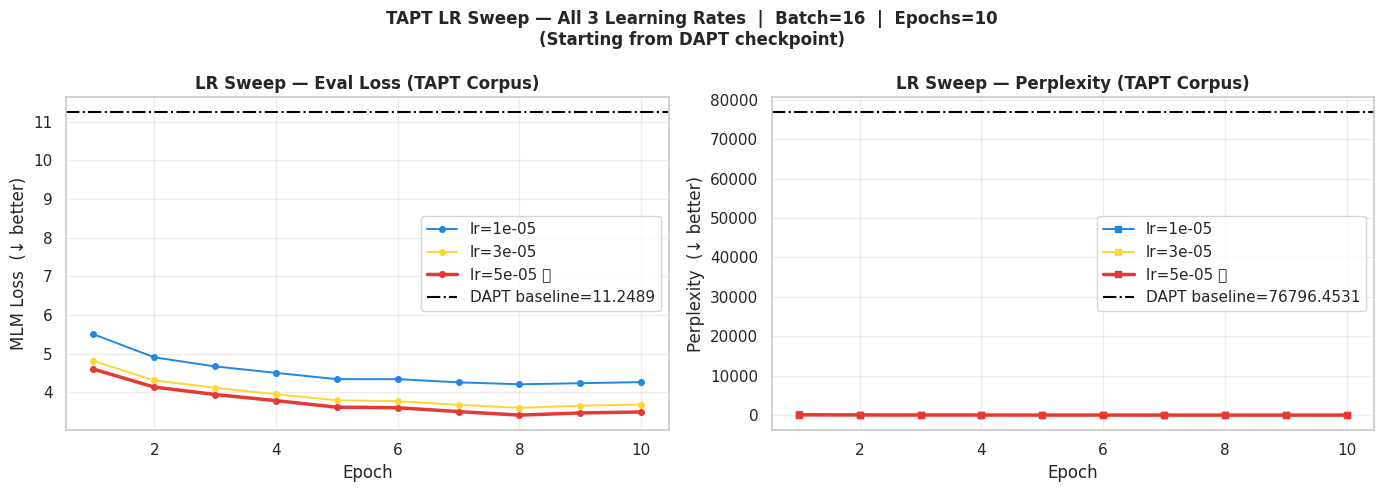

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/tapt/tapt_lr_sweep.png


In [15]:
sns.set_theme(style='whitegrid', font_scale=1.0)
LR_COLORS = {1e-5: '#1E88E5', 3e-5: '#FDD835', 5e-5: '#E53935'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax = axes[0]
for lr_key, res in SWEEP_RESULTS.items():
    ldf = res['log_df']
    lr  = res['lr']
    lw  = 2.5 if lr == BEST_LR else 1.4
    ax.plot(ldf['epoch'], ldf['eval_loss'], lw=lw, color=LR_COLORS[lr],
            marker='o', ms=4,
            label=f'{lr_key}' + (' ⭐' if lr == BEST_LR else ''))
ax.axhline(BASE_METRICS['loss'], color='black', ls='-.', lw=1.5,
           label=f'DAPT baseline={BASE_METRICS["loss"]:.4f}')
ax.set_title('LR Sweep — Eval Loss (TAPT Corpus)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MLM Loss  (↓ better)')
ax.legend(); ax.grid(alpha=0.35)

# Perplexity curves
ax = axes[1]
for lr_key, res in SWEEP_RESULTS.items():
    ldf = res['log_df']
    lr  = res['lr']
    lw  = 2.5 if lr == BEST_LR else 1.4
    ax.plot(ldf['epoch'], ldf['perplexity'], lw=lw, color=LR_COLORS[lr],
            marker='s', ms=4,
            label=f'{lr_key}' + (' ⭐' if lr == BEST_LR else ''))
ax.axhline(BASE_METRICS['perplexity'], color='black', ls='-.', lw=1.5,
           label=f'DAPT baseline={BASE_METRICS["perplexity"]:.4f}')
ax.set_title('LR Sweep — Perplexity (TAPT Corpus)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity  (↓ better)')
ax.legend(); ax.grid(alpha=0.35)

plt.suptitle(
    f'TAPT LR Sweep — All 3 Learning Rates  |  Batch={CFG["sweep_batch"]}  |  '
    f'Epochs={CFG["sweep_epochs"]}\n(Starting from DAPT checkpoint)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/tapt_lr_sweep.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

In [17]:
print(f'🚀 Full TAPT Run')
print(f'   Starting from : Base MiniLM ({CFG["base_model"]})')
print(f'   Best LR       : {BEST_LR:.0e}')
print(f'   Epochs        : {CFG["tapt_epochs"]}  (dynamic masking)')
print(f'   Early stop    : patience={CFG["early_stop_patience"]}')

# Start from base MiniLM
tapt_model = AutoModelForMaskedLM.from_pretrained(CFG['base_model'])

logger_tapt     = DetailedLoggerCallback()
steps_per_epoch = math.ceil(len(train_ds) / CFG['full_batch'])
total_steps     = steps_per_epoch * CFG['tapt_epochs']
warmup_steps    = max(1, int(total_steps * CFG['warmup_ratio']))

args_tapt = TrainingArguments(
    output_dir                  = PATHS['model_dir'],
    num_train_epochs            = CFG['tapt_epochs'],
    per_device_train_batch_size = CFG['full_batch'],
    per_device_eval_batch_size  = 64,
    learning_rate               = BEST_LR,
    weight_decay                = CFG['weight_decay'],
    warmup_steps                = warmup_steps,
    lr_scheduler_type           = 'cosine',
    fp16                        = False,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,
    save_total_limit            = 2,
    logging_steps               = max(5, steps_per_epoch // 4),
    report_to                   = 'none',
    seed                        = CFG['seed'],
    dataloader_num_workers      = 2,
    push_to_hub                 = False,
)

trainer_tapt = Trainer(
    model         = tapt_model,
    args          = args_tapt,
    train_dataset = train_ds,
    eval_dataset  = eval_ds,
    data_collator = collator,
    callbacks     = [
        logger_tapt,
        EarlyStoppingCallback(early_stopping_patience=CFG['early_stop_patience']),
    ],
)

t_tapt = time.time()
trainer_tapt.train()
tapt_time = time.time() - t_tapt

log_df_tapt = pd.DataFrame(logger_tapt.records)
trainer_tapt.save_model(PATHS['model_dir'])
tokenizer.save_pretrained(PATHS['model_dir'])
log_df_tapt.to_csv(PATHS['log_csv'], index=False)

actual_epochs = log_df_tapt['epoch'].max()
print(f'\n✅ TAPT done in {tapt_time/60:.1f} min')
print(f'   Epochs run     : {actual_epochs}')
print(f'   Best eval loss : {log_df_tapt["eval_loss"].min():.6f}')
print(f'   Best PPL       : {log_df_tapt["perplexity"].min():.4f}')
print(f'   Model saved    → {PATHS["model_dir"]}')

🚀 Full TAPT Run
   Starting from : Base MiniLM (microsoft/MiniLM-L12-H384-uncased)
   Best LR       : 5e-05
   Epochs        : 50  (dynamic masking)
   Early stop    : patience=5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertForMaskedLM LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
pooler.dense.bias                          | UNEXPECTED | 
pooler.dense.weight                        | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.decoder.bias               | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.bias                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if

Epoch,Training Loss,Validation Loss
1,5.697515,5.354150
2,4.731635,4.574057
3,4.311716,4.251119
4,4.010627,3.949269
5,3.863070,3.750917
6,3.680967,3.687695
7,3.575339,3.584323
8,3.513009,3.460425
9,3.396555,3.471875
10,3.343976,3.446863


  Ep   1 | Train 7.0392 | Eval 5.3541 | PPL 211.484 | LR nan


...

  Ep  50 | Train 2.4480 | Eval 2.9008 | PPL 18.188 | LR nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ TAPT done in 124.2 min
   Epochs run     : 50
   Best eval loss : 2.885643
   Best PPL       : 17.9151
   Model saved    → /content/drive/MyDrive/Rajdeep_Document/models/final/tapt_minilm_climate


In [18]:
print('📏 Computing AFTER-TAPT metrics...')
final_model = AutoModelForMaskedLM.from_pretrained(
    PATHS['model_dir'], attn_implementation='eager'
).to(DEVICE)

TAPT_METRICS = compute_perplexity(
    final_model, eval_ds, collator, batch_size=64, desc='Post-TAPT'
)

loss_delta = TAPT_METRICS['loss']       - BASE_METRICS['loss']
ppl_delta  = TAPT_METRICS['perplexity'] - BASE_METRICS['perplexity']
loss_pct   = loss_delta / BASE_METRICS['loss']       * 100
ppl_pct    = ppl_delta  / BASE_METRICS['perplexity'] * 100

print(f'\n{"Stage":<25} {"Loss":>10}  {"Perplexity":>12}')
print('-' * 50)
print(f'{"Base MiniLM":<25} {BASE_METRICS["loss"]:>10.4f}  {BASE_METRICS["perplexity"]:>12.4f}')
print(f'{"TAPT MiniLM":<25} {TAPT_METRICS["loss"]:>10.4f}  {TAPT_METRICS["perplexity"]:>12.4f}')
print(f'{"Delta":<25} {loss_delta:>+10.4f}  {ppl_delta:>+12.4f}')
print(f'{"% Change":<25} {loss_pct:>+10.2f}%  {ppl_pct:>+12.2f}%')

verdict = 'TAPT SUCCESSFUL' if TAPT_METRICS['perplexity'] < BASE_METRICS['perplexity'] \
          else 'WARNING: perplexity did not improve — check LR or corpus quality'
print(f'\n  {verdict}')

📏 Computing AFTER-TAPT metrics...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Post-TAPT:   0%|          | 0/25 [00:00<?, ?it/s]


Stage                           Loss    Perplexity
--------------------------------------------------
Base MiniLM                  11.2489    76796.4531
TAPT MiniLM                   3.8191       45.5644
Delta                        -7.4298   -76750.8887
% Change                      -66.05%        -99.94%

  TAPT SUCCESSFUL


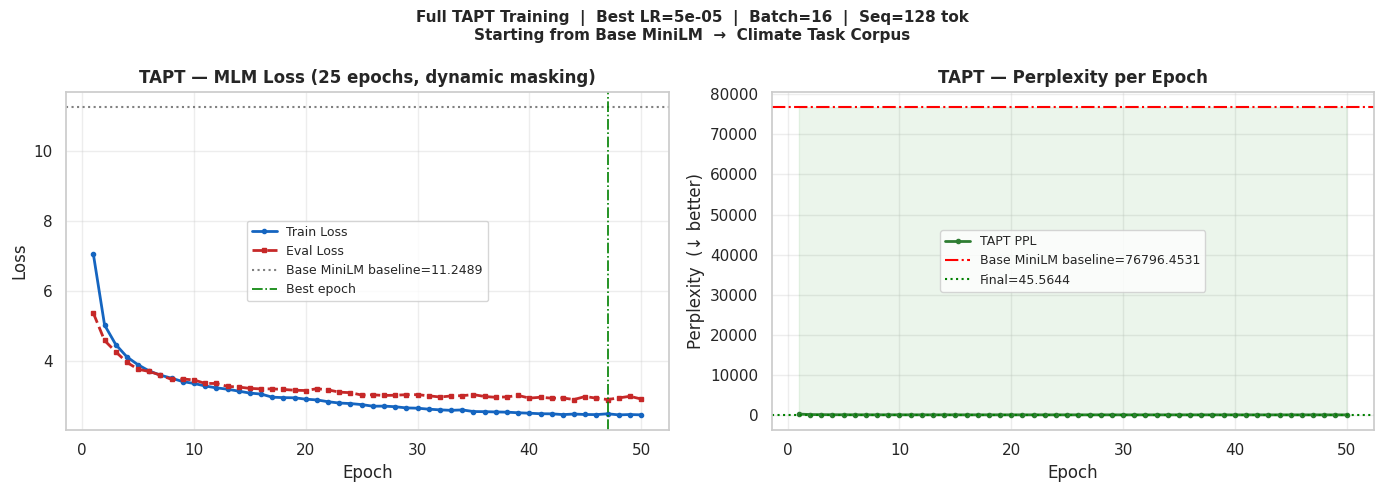

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/tapt/tapt_training_curve.png


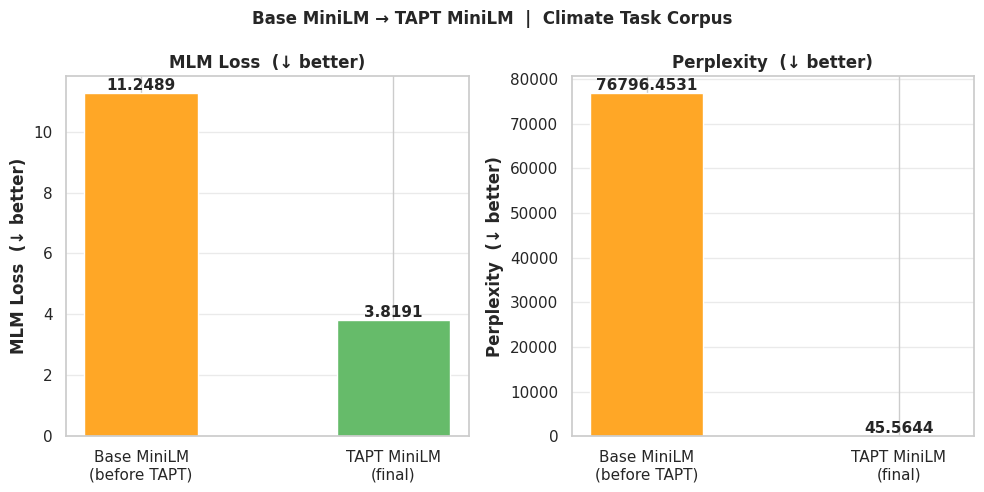

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/tapt/tapt_2stage_comparison.png


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertForMaskedLM LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
pooler.dense.bias                          | UNEXPECTED | 
pooler.dense.weight                        | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.decoder.bias               | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.bias                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

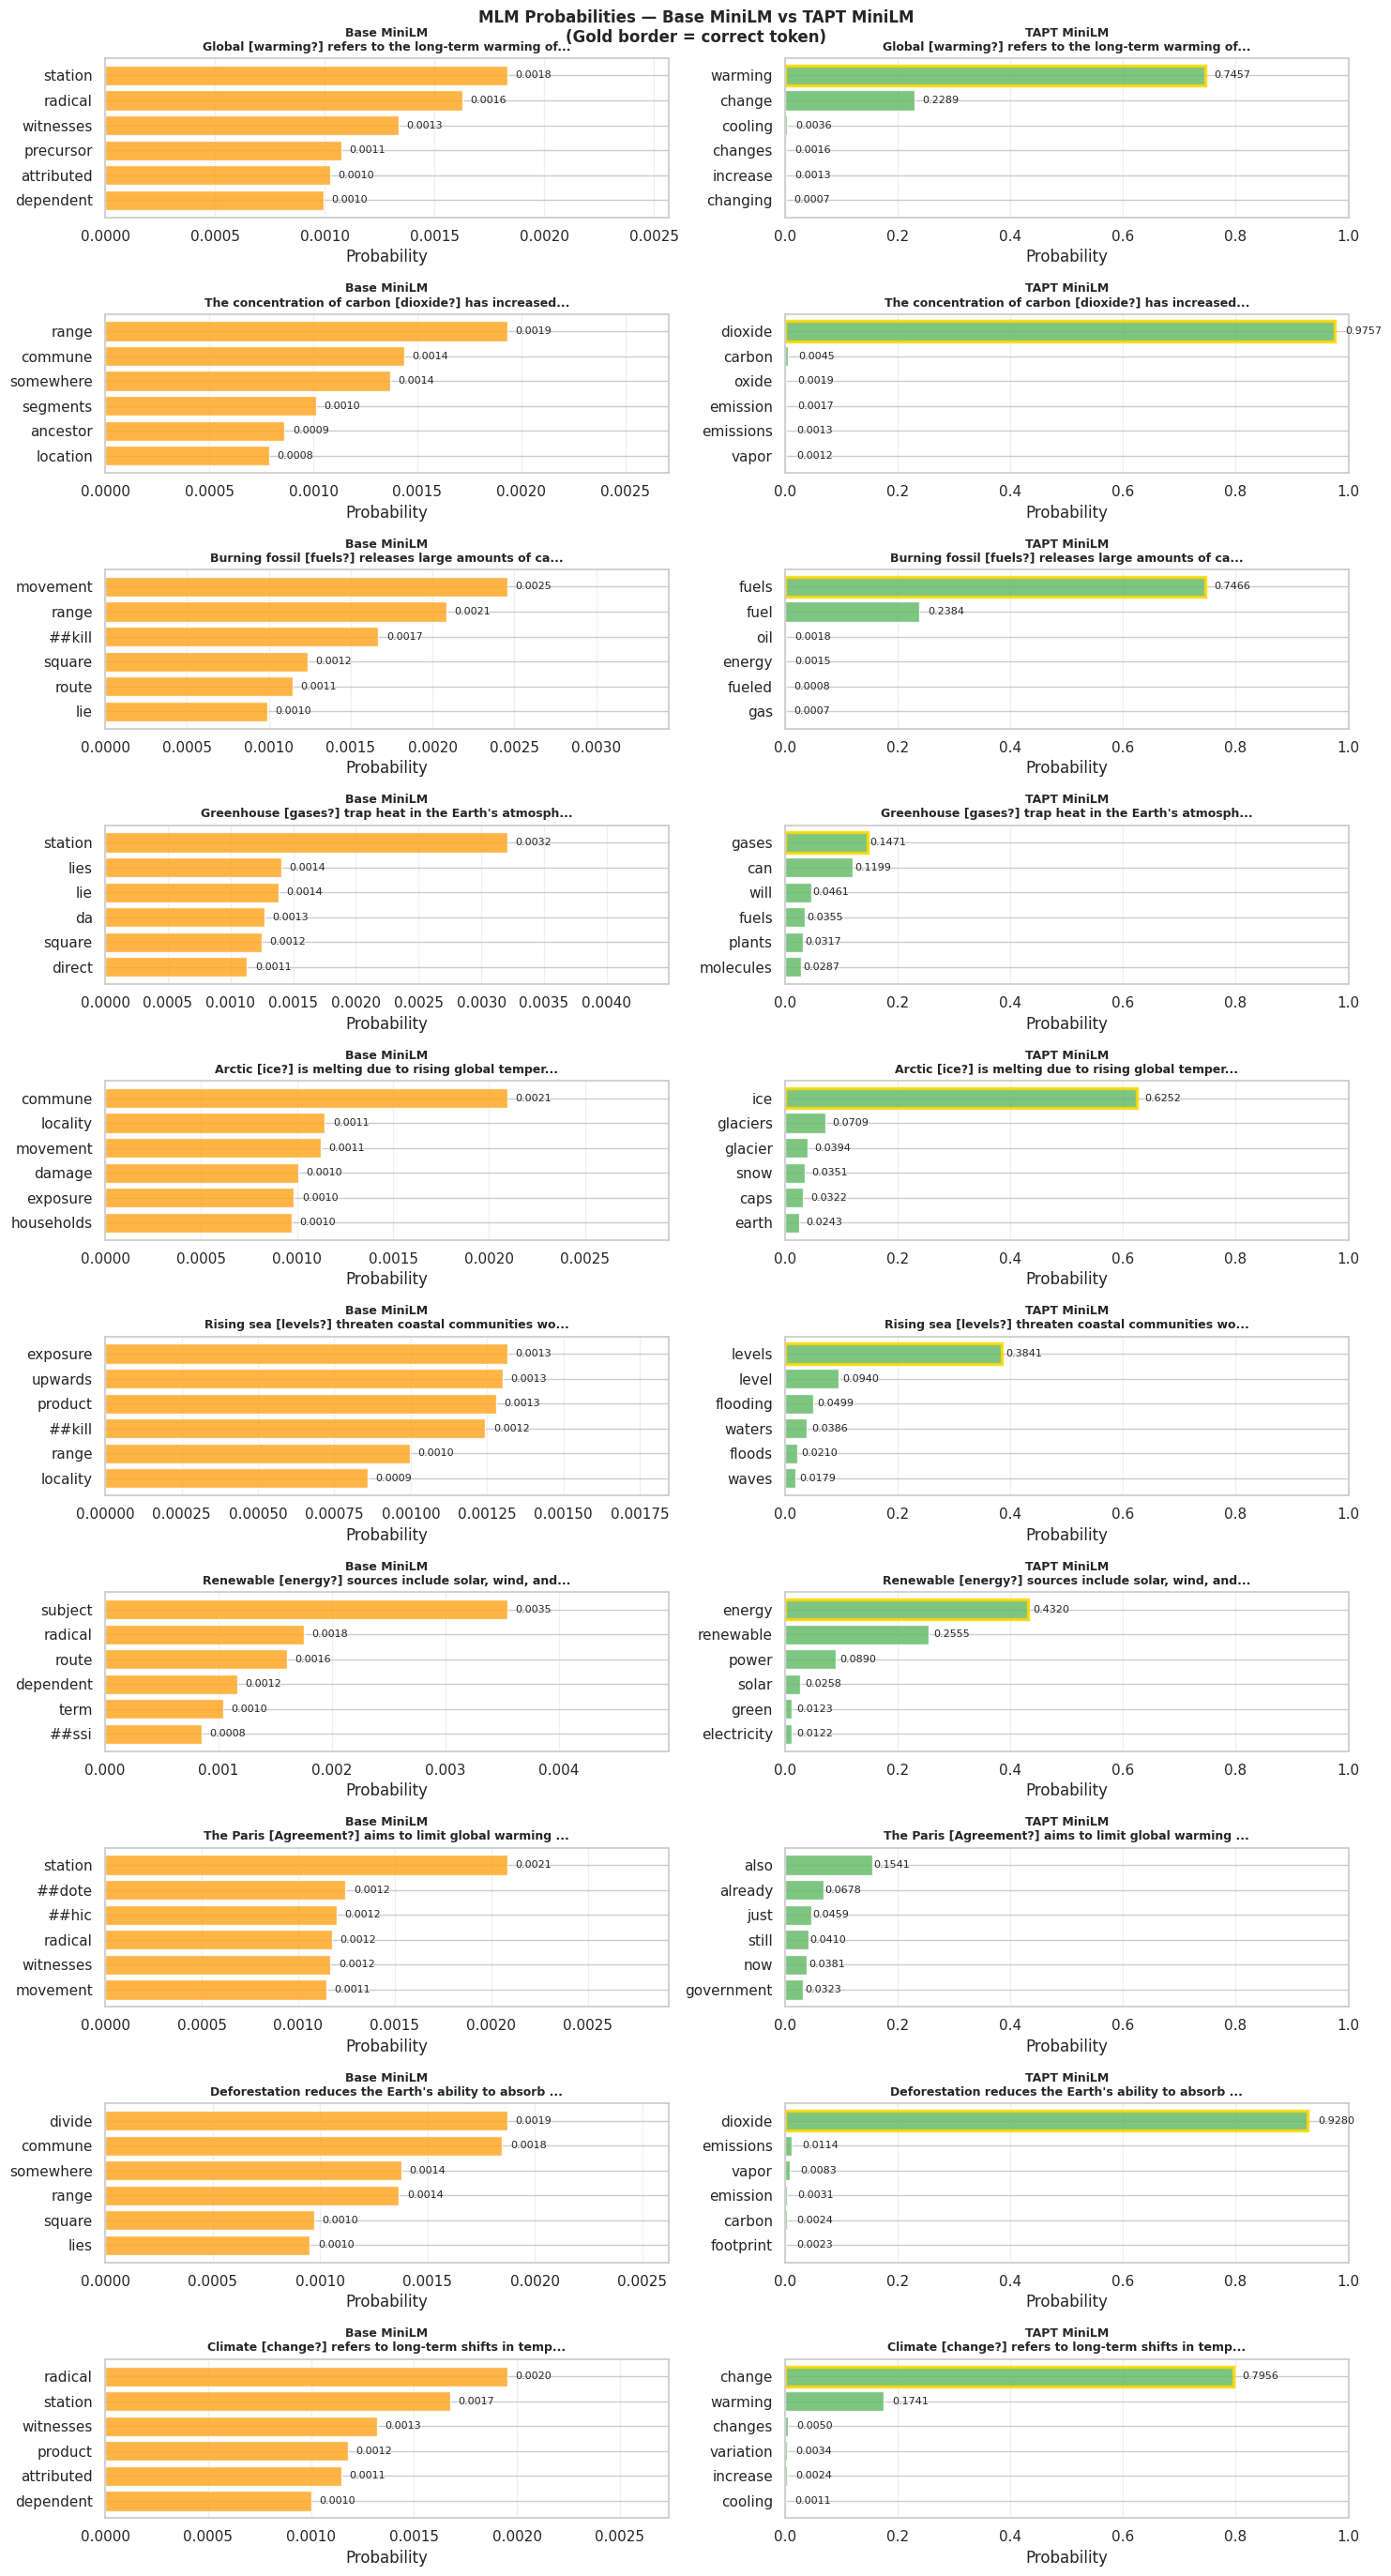

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/tapt/tapt_mlm_probabilities.png

Probe                                          Base MiniLM      TAPT     Delta
--------------------------------------------------------------------------------
✅  Global [warming] refers to the long-term wa       0.0000    0.7457   +0.7457
✅  The concentration of carbon [dioxide] has i       0.0000    0.9757   +0.9757
✅  Burning fossil [fuels] releases large amoun       0.0000    0.7466   +0.7466
✅  Greenhouse [gases] trap heat in the Earth's       0.0000    0.1471   +0.1471
✅  Arctic [ice] is melting due to rising globa       0.0000    0.6252   +0.6252
✅  Rising sea [levels] threaten coastal commun       0.0000    0.3841   +0.3841
✅  Renewable [energy] sources include solar, w       0.0000    0.4320   +0.4320
⚠️   The Paris [Agreement] aims to limit global        0.0000    0.0000   +0.0000
✅  Deforestation reduces the Earth's ability t       0.0000    0.9280   +0.9280
✅  Climate [change] refers to

In [27]:
sns.set_theme(style='whitegrid', font_scale=1.0)

# ── PLOT A: Full TAPT training curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(log_df_tapt['epoch'], log_df_tapt['train_loss'], lw=2,
        color='#1565C0', marker='o', ms=3, label='Train Loss')
ax.plot(log_df_tapt['epoch'], log_df_tapt['eval_loss'],  lw=2, ls='--',
        color='#C62828', marker='s', ms=3, label='Eval Loss')
ax.axhline(BASE_METRICS['loss'], color='gray', ls=':', lw=1.5,
           label=f'Base MiniLM baseline={BASE_METRICS["loss"]:.4f}')   # ← fixed
best_ep = log_df_tapt['eval_loss'].idxmin()
ax.axvline(log_df_tapt['epoch'].iloc[best_ep], color='green',
           ls='-.', lw=1.2, label='Best epoch')
ax.set_title('TAPT — MLM Loss (25 epochs, dynamic masking)', fontweight='bold')  # ← fixed
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(alpha=0.35)

ax = axes[1]
ax.plot(log_df_tapt['epoch'], log_df_tapt['perplexity'], lw=2,
        color='#2E7D32', marker='o', ms=3, label='TAPT PPL')
ax.axhline(BASE_METRICS['perplexity'], color='red', ls='-.', lw=1.5,
           label=f'Base MiniLM baseline={BASE_METRICS["perplexity"]:.4f}')  # ← fixed
ax.axhline(TAPT_METRICS['perplexity'], color='green', ls=':', lw=1.5,
           label=f'Final={TAPT_METRICS["perplexity"]:.4f}')
ax.fill_between(log_df_tapt['epoch'], log_df_tapt['perplexity'],
                BASE_METRICS['perplexity'], alpha=0.08, color='green')
ax.set_title('TAPT — Perplexity per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity  (↓ better)')
ax.legend(fontsize=9); ax.grid(alpha=0.35)

plt.suptitle(
    f'Full TAPT Training  |  Best LR={BEST_LR:.0e}  |  '
    f'Batch={CFG["full_batch"]}  |  Seq={CFG["seq_len"]} tok\n'
    f'Starting from Base MiniLM  →  Climate Task Corpus',   # ← fixed
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/tapt_training_curve.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# ── PLOT B: 2-stage comparison bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

stages       = ['Base MiniLM\n(before TAPT)', 'TAPT MiniLM\n(final)']   # ← fixed
loss_vals    = [BASE_METRICS['loss'],       TAPT_METRICS['loss']]
ppl_vals     = [BASE_METRICS['perplexity'], TAPT_METRICS['perplexity']]
stage_colors = ['#FFA726', '#66BB6A']

for ax, vals, ylabel in [
    (axes[0], loss_vals, 'MLM Loss  (↓ better)'),
    (axes[1], ppl_vals,  'Perplexity  (↓ better)'),
]:
    bars = ax.bar(stages, vals, color=stage_colors, edgecolor='white', width=0.45)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(ylabel, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Base MiniLM → TAPT MiniLM  |  Climate Task Corpus',   # ← fixed
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/tapt_2stage_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# ── PLOT C: MLM fill-mask probes Base MiniLM vs TAPT ─────────────────────────
from transformers import pipeline as hf_pipeline

MASK         = tokenizer.mask_token
fill_base    = hf_pipeline('fill-mask', model=CFG['base_model'],   # ← fixed: base MiniLM
                            device=0 if torch.cuda.is_available() else -1)
fill_tapt    = hf_pipeline('fill-mask', model=PATHS['model_dir'],
                            device=0 if torch.cuda.is_available() else -1)

PROBES = [
    (f"Global {MASK} refers to the long-term warming of the planet.",            'warming'),
    (f"The concentration of carbon {MASK} has increased rapidly.",               'dioxide'),
    (f"Burning fossil {MASK} releases large amounts of carbon dioxide.",         'fuels'),
    (f"Greenhouse {MASK} trap heat in the Earth's atmosphere.",                  'gases'),
    (f"Arctic {MASK} is melting due to rising global temperatures.",             'ice'),
    (f"Rising sea {MASK} threaten coastal communities worldwide.",               'levels'),
    (f"Renewable {MASK} sources include solar, wind, and hydro power.",         'energy'),
    (f"The Paris {MASK} aims to limit global warming to 1.5 degrees Celsius.",  'Agreement'),
    (f"Deforestation reduces the Earth's ability to absorb carbon {MASK}.",     'dioxide'),
    (f"Climate {MASK} refers to long-term shifts in temperatures and weather.",  'change'),
]

def plot_fill_bar(ax, results, title, color, expected, auto_scale=False):
    toks = [r['token_str'].strip() for r in results]
    scs  = [r['score'] for r in results]
    bars = ax.barh(toks[::-1], scs[::-1], color=color, alpha=0.85, edgecolor='white')
    for bar, sc in zip(bars, scs[::-1]):
        ax.text(bar.get_width() + max(scs)*0.02, bar.get_y() + bar.get_height()/2,
                f'{sc:.4f}', va='center', fontsize=8)
    for i, t in enumerate(toks[::-1]):
        if t.lower() == expected.lower():
            bars[i].set_edgecolor('gold'); bars[i].set_linewidth(2.5)

    # ── auto_scale=True for base model so tiny bars are visible ───
    if auto_scale:
        ax.set_xlim(0, max(scs) * 1.4)   # scale to actual max, not 0–1
    else:
        ax.set_xlim(0, 1.0)

    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Probability'); ax.grid(axis='x', alpha=0.3)

fig, axes = plt.subplots(len(PROBES), 2, figsize=(15, len(PROBES) * 2.8))

for row, (sent, expected) in enumerate(PROBES):
    rb = fill_base(sent, top_k=6)
    rt = fill_tapt(sent, top_k=6)
    short = sent.replace(MASK, f'[{expected}?]')[:52] + '...'
    plot_fill_bar(axes[row][0], rb, f'Base MiniLM\n{short}',
                  '#FFA726', expected, auto_scale=True)   # ← auto scale left
    plot_fill_bar(axes[row][1], rt, f'TAPT MiniLM\n{short}',
                  '#66BB6A', expected, auto_scale=False)  # ← fixed 0–1 right # ← fixed

plt.suptitle('MLM Probabilities — Base MiniLM vs TAPT MiniLM\n(Gold border = correct token)',  # ← fixed
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/tapt_mlm_probabilities.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# Numeric summary
print(f'\n{"Probe":<45}  {"Base MiniLM":>11}  {"TAPT":>8}  {"Delta":>8}')  # ← fixed
print('-'*80)
for sent, expected in PROBES:
    rb = fill_base(sent, top_k=50); rt = fill_tapt(sent, top_k=50)  # ← fixed
    def gp(res, tok):
        for r in res:
            if r['token_str'].strip().lower() == tok.lower(): return r['score']
        return 0.0
    pb = gp(rb, expected); pt = gp(rt, expected)   # ← fixed: pb not pd_
    lbl = sent.replace(MASK, f'[{expected}]')[:43]
    print(f'{"✅" if pt > pb else "⚠️ "}  {lbl:43s}  {pb:11.4f}  {pt:8.4f}  {pt-pb:+8.4f}')

In [28]:
eval_results = {
    'dapt_baseline' : BASE_METRICS,
    'after_tapt'    : TAPT_METRICS,
    'improvement'   : {
        'loss_pct_change': round(loss_pct, 4),
        'ppl_pct_change' : round(ppl_pct,  4),
    },
    'tapt_config'   : {
        'best_lr'           : BEST_LR,
        'batch_size'        : CFG['full_batch'],
        'epochs_configured' : CFG['tapt_epochs'],
        'epochs_actual'     : int(log_df_tapt['epoch'].max()),
        'early_stopped'     : int(log_df_tapt['epoch'].max()) < CFG['tapt_epochs'],
        'seq_len'           : CFG['seq_len'],
        'mlm_probability'   : CFG['mlm_probability'],
        'dynamic_masking'   : True,
        'start_checkpoint'  : 'Base MiniLM',
    },
    'timestamp' : datetime.now().isoformat(),
}

with open(PATHS['eval_json'], 'w') as f:
    json.dump(eval_results, f, indent=2)

report = f"""
╔═══════════════════════════════════════════════════════════════╗
║        TAPT FINAL REPORT — Climate Task Corpus               ║
╚═══════════════════════════════════════════════════════════════╝
Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

TRAINING STRATEGY
  Pipeline         : Base MiniLM → TAPT
  Start Checkpoint : Base MiniLM ({CFG['base_model']})
  Task             : Masked Language Modeling — dynamic masking
  LR Sweep values  : {TAPT_LR_SWEEP}
  Best LR          : {BEST_LR:.0e}
  Batch size       : {CFG['full_batch']}
  Seq length       : {CFG['seq_len']} tokens
  Epochs target    : {CFG['tapt_epochs']}
  Epochs actual    : {int(log_df_tapt['epoch'].max())}  (early stop patience={CFG['early_stop_patience']})

METRICS
  Stage             Loss          Perplexity
  DAPT baseline  : {BASE_METRICS['loss']:.6f}     {BASE_METRICS['perplexity']:.4f}
  TAPT           : {TAPT_METRICS['loss']:.6f}     {TAPT_METRICS['perplexity']:.4f}
  Improvement    : {loss_pct:+.2f}% loss  |  {ppl_pct:+.2f}% perplexity

PLOTS SAVED
  tapt_lr_sweep.png           — 3 LR curves during sweep
  tapt_training_curve.png     — full 100-epoch loss + PPL
  tapt_2stage_comparison.png  — DAPT vs TAPT bar chart
  tapt_mlm_probabilities.png  — fill-mask DAPT vs TAPT

VERDICT
  {verdict}
"""

with open(PATHS['report_txt'], 'w') as f:
    f.write(report)
print(report)
print(f'✅ Report   → {PATHS["report_txt"]}')
print(f'✅ Eval JSON → {PATHS["eval_json"]}')


╔═══════════════════════════════════════════════════════════════╗
║        TAPT FINAL REPORT — Climate Task Corpus               ║
╚═══════════════════════════════════════════════════════════════╝
Generated : 2026-05-28 10:40:09

TRAINING STRATEGY
  Pipeline         : Base MiniLM → TAPT
  Start Checkpoint : Base MiniLM (microsoft/MiniLM-L12-H384-uncased)
  Task             : Masked Language Modeling — dynamic masking
  LR Sweep values  : [1e-05, 3e-05, 5e-05]
  Best LR          : 5e-05
  Batch size       : 16
  Seq length       : 128 tokens
  Epochs target    : 50
  Epochs actual    : 50  (early stop patience=5)

METRICS
  Stage             Loss          Perplexity
  DAPT baseline  : 11.248914     76796.4531
  TAPT           : 3.819127     45.5644
  Improvement    : -66.05% loss  |  -99.94% perplexity

PLOTS SAVED
  tapt_lr_sweep.png           — 3 LR curves during sweep
  tapt_training_curve.png     — full 100-epoch loss + PPL
  tapt_2stage_comparison.png  — DAPT vs TAPT bar chart
  t